# SFO 1-Hour and 12-Hour Flight Delay Baseline Model

In [5]:
#libraries
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import os

In [6]:
print(os.getcwd())

/Users/justin/DATASCI207/207-Summer26-FinalProject-MLModel/Baseline_Model


## Load data

In [9]:
# load .csv files into data frames
one_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_1h.csv")
twelve_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_12h.csv")

In [10]:
# check shape of both data frames
print("1hr df shape:", one_df.shape)
print("12hr df shape:", twelve_df.shape)

1hr df shape: (334086, 32)
12hr df shape: (346464, 32)


In [11]:
# check column names
print("one_df columns:\n", one_df.columns.tolist())

one_df columns:
 ['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code', 'destination_airport', 'scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'model', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h', 'departure_delay_minutes']


In [12]:
# check column names
print("twelve_df columns:\n", twelve_df.columns.tolist())

twelve_df columns:
 ['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code', 'destination_airport', 'scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'model', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h', 'departure_delay_minutes']


In [14]:
# lets check the date range for each df
print("1hr date range:", one_df['date'].min(), one_df['date'].max())
print("12hr date range:", twelve_df['date'].min(), twelve_df['date'].max())

1hr date range: 2022-01-01 2026-04-30
12hr date range: 2022-01-01 2026-04-30


In [27]:
# check for missing values in df
print("one_df missing value count:", one_df.isnull().sum())
print("twellve_df missing value count:", twelve_df.isnull().sum())

one_df missing value count: date                              0
scheduled_dep_dt                  0
actual_dep_dt                     0
carrier_code                      0
destination_airport               0
scheduled_elapsed_time_minutes    0
year                              0
month                             0
day_of_week                       0
is_weekend                        0
sched_dep_hour                    0
outcome                           0
days_until_holiday                0
days_from_holiday                 0
year_mfr                          0
model                             0
no_seats                          0
visibility                        0
ceiling_height                    0
wind_speed                        0
wind_direction                    0
temperature                       0
dew_point_temperature             0
relative_humidity                 0
altimeter                         0
aircraft_age                      0
week_num                          0


## Split the data into Train/Validation/Test

We will use a split as follows\
Train: 2022-01-01 to 2024-12-31\
Validate: 2025-01-01 to 2025-12-31\
Test: 2026-01-01 to 2026-04-03

In [20]:
# 1-hour data
one_train_df = one_df[
    (one_df['date'] >= "2022-01-01") &
    (one_df['date'] <= "2024-12-31")
]
one_val_df = one_df[
    (one_df['date'] >= "2025-01-01") &
    (one_df['date'] <= "2025-12-31")
]
one_test_df = one_df[
    (one_df['date'] >= "2026-01-01") &
    (one_df['date'] <= "2026-04-30")
]

In [21]:
print("1-hr. train shape:", one_train_df.shape)
print("1-hr. val shape:", one_val_df.shape)
print("1-hr. test shape:", one_test_df.shape)

1-hr. train shape: (236106, 32)
1-hr. val shape: (81325, 32)
1-hr. test shape: (16655, 32)


In [22]:
# 12-hour data
twelve_train_df = twelve_df[
    (twelve_df['date'] >= "2022-01-01") &
    (twelve_df['date'] <= "2024-12-31")
]
twelve_val_df = twelve_df[
    (twelve_df['date'] >= "2025-01-01") &
    (twelve_df['date'] <= "2025-12-31")
]
twelve_test_df = twelve_df[
    (twelve_df['date'] >= "2026-01-01") &
    (twelve_df['date'] <= "2026-04-30")
]

In [23]:
print("12-hour train shape:", twelve_train_df.shape)
print("12-hour val shape:", twelve_val_df.shape)
print("12-hour test shape:", twelve_test_df.shape)

12-hour train shape: (245694, 32)
12-hour val shape: (83399, 32)
12-hour test shape: (17371, 32)


## Feature selection (simple style) & X-y split

In [24]:
# numeric only feature selection
features = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h",
]

target = "departure_delay_minutes"

In [28]:
# separate train/val/test with features and target variables for X, y
## for one_df
one_X_train = one_train_df[features]
one_y_train = one_train_df[target]

one_X_val = one_val_df[features]
one_y_val = one_val_df[target]

one_X_test = one_test_df[features]
one_y_test = one_test_df[target]

## for twelve_df
twelve_X_train = twelve_train_df[features]
twelve_y_train = twelve_train_df[target]

twelve_X_val = twelve_val_df[features]
twelve_y_val = twelve_val_df[target]

twelve_X_test = twelve_test_df[features]
twelve_y_test = twelve_test_df[target]

## Scale features for optimal performance

In [33]:
# one hour transforms
# get scaler
one_scaler = StandardScaler()
one_scaler.fit(one_X_train)
# scale one
one_X_train_std = one_scaler.transform(one_X_train)
one_X_val_std = one_scaler.transform(one_X_val)
one_X_test_std = one_scaler.transform(one_X_test)

# twelve hour transforms
# get scaler
twelve_scaler = StandardScaler()
twelve_scaler.fit(twelve_X_train)
# scale twelve
twelve_X_train_std = twelve_scaler.transform(twelve_X_train)
twelve_X_val_std = twelve_scaler.transform(twelve_X_val)
twelve_X_test_std = twelve_scaler.transform(twelve_X_test)

In [39]:
print("1hr train mean for first 5:", one_X_train_std.mean(axis=0)[:5])
print("1hr train std for first 5: ", one_X_train_std.std(axis=0)[:5])
print("12hr train mean for first 5:", twelve_X_train_std.mean(axis=0)[:5])
print("12hr train std for first 5:", twelve_X_train_std.std(axis=0)[:5])

1hr train mean for first 5: [-4.47802085e-17  9.47992199e-15  1.54082438e-16 -1.92603047e-16
  9.72645389e-17]
1hr train std for first 5:  [1. 1. 1. 1. 1.]
12hr train mean for first 5: [-1.20537828e-16  1.45922494e-14 -1.33262551e-16 -1.58480638e-16
 -1.80459705e-17]
12hr train std for first 5: [1. 1. 1. 1. 1.]


## Baseline Linear Regression Model

In [46]:
# build regression model with single dense layer
def build_model(num_features, learning_rate):
    tf.keras.backend.clear_session() # reset model
    tf.random.set_seed(0) # reproducible seed

    # build the model
    model = tf.keras.Sequential([ 
        tf.keras.Input(shape=(num_features,)), # use features for input, define how many
        tf.keras.layers.Dense(units=1, use_bias=True) # output single number
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) # use the Adam optimizer

    # use Adam for weight optimization, MSE for prediction error
    model.compile( 
        optimizer=optimizer,
        loss="mse", # compute loss as mean squared error
        metrics=["mae"] # convert MSE back into minutes
    )

    return model

In [47]:
# confirm model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
# build model for both 1-hr and 12-hr data
one_model = build_model(one_X_train_std.shape[1], learning_rate=0.001)
twelve_model = build_model(twelve_X_train_std.shape[1], learning_rate=0.001)

In [49]:
# confirmn model
one_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Models (1-hour and 12-hour)

In [59]:
# train models
one_history = one_model.fit(
    one_X_train_std,
    one_y_train,
    validation_data=(one_X_val_std, one_y_val),
    epochs=30,
    batch_size=256
)

Epoch 1/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1548.8690 - mae: 19.6490 - val_loss: 1680.3315 - val_mae: 22.7785
Epoch 2/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1548.8694 - mae: 19.6491 - val_loss: 1680.3313 - val_mae: 22.7786
Epoch 3/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1548.8696 - mae: 19.6491 - val_loss: 1680.3313 - val_mae: 22.7787
Epoch 4/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1548.8695 - mae: 19.6492 - val_loss: 1680.3300 - val_mae: 22.7788
Epoch 5/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1548.8690 - mae: 19.6492 - val_loss: 1680.3303 - val_mae: 22.7789
Epoch 6/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1548.8688 - mae: 19.6492 - val_loss: 1680.3296 - val_mae: 22.7789
Epoch 7/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1548.8688 - mae: 19.6493 - val_loss: 1680.3303 - val_mae: 22.7790
Epoch 8/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1548.8680 - mae: 19.6493 - val_loss: 1680.3296 - val_mae: 

1-hour results: 

predictions on 1-hour training are off by about 19.65 minutes,   
while applied to the validation data off by about 22.78 minutes

In [54]:
# twelve hour train
twelve_history = twelve_model.fit(
    twelve_X_train_std, twelve_y_train,
    validation_data=(twelve_X_val_std, twelve_y_val),
    epochs=30,
    batch_size=256
)

Epoch 1/30
  1/960 ━━━━━━━━━━━━━━━━━━━━ 3:42 232ms/step - loss: 3638.6238 - mae: 18.2967

2026-07-10 09:49:29.050948: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1696.0181 - mae: 16.3852 - val_loss: 1705.4052 - val_mae: 17.0618
Epoch 2/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1669.9967 - mae: 16.4950 - val_loss: 1677.3158 - val_mae: 17.7063
Epoch 3/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1650.6398 - mae: 16.6930 - val_loss: 1660.1649 - val_mae: 18.3484
Epoch 4/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1635.1727 - mae: 16.9215 - val_loss: 1649.9087 - val_mae: 18.9586
Epoch 5/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1622.3668 - mae: 17.1690 - val_loss: 1644.1776 - val_mae: 19.5307
Epoch 6/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1611.6414 - mae: 17.4324 - val_loss: 1641.5441 - val_mae: 20.0667
Epoch 7/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1602.6899 - mae: 17.7095 - val_loss: 1641.1226 - val_mae: 20.5710
Epoch 8/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1595.3307 - mae: 17.9958 - val_loss: 1642.3270 - val_mae: 21.0451
Epo

Results for 12-hour:  
Training is off about 20.05 minutes,  
Validation is off by 23.69 minutes.
*validation lowest at epoch 6 for 19.53 minutes and training of 17.16 minutes

### Train and Validation Performance Plots

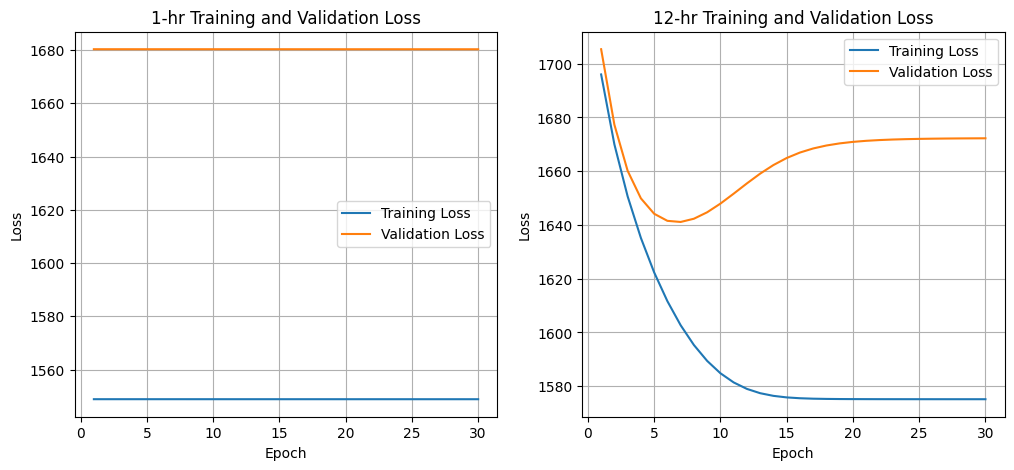

In [63]:
# get axis parameters
num_epochs = len(one_history.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# plot one_hour
plt.subplot(1,2,1)
plt.plot(epochs, one_history.history["loss"], label="Training Loss")
plt.plot(epochs, one_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1-hr Training and Validation Loss")
plt.legend()
plt.grid()

# plot twelve hour model
plt.subplot(1,2,2)
plt.plot(epochs, twelve_history.history["loss"], label="Training Loss")
plt.plot(epochs, twelve_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("12-hr Training and Validation Loss")
plt.legend()
plt.grid()

### Evaluate Baseline Model Results

In [83]:
# run trained model on dataset and evaluate performance
one_test_loss, one_test_mae = one_model.evaluate(one_X_test_std, one_y_test)
twelve_test_loss, twelve_test_mae = twelve_model.evaluate(twelve_X_test_std, twelve_y_test)
# print out performance results
print(f"1-hr test loss MSE: {one_test_loss:.4f}, test MAE: {one_test_mae}")
print(f"12-hr test loss MSE: {twelve_test_loss:.4f}, test MAE: {twelve_test_mae}")

521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1557.4923 - mae: 24.0333
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1601.2847 - mae: 25.2434
1-hr test loss MSE: 1557.4923, test MAE: 24.033266067504883
12-hr test loss MSE: 1601.2847, test MAE: 25.24335289001465


## Classification Model

### 1-hour model

In [68]:
cl_target = "outcome" # use outcome to predict 9 categories of delay

# split data into train, val, and test
# use same feature set as regression model
one_X_train_cl = one_train_df[features]
one_y_train_cl = one_train_df[cl_target]
one_X_val_cl = one_val_df[features]
one_y_val_cl = one_val_df[cl_target]
one_X_test_cl = one_test_df[features]
one_y_test_cl = one_test_df[cl_target]

# scale the train, val, test data
one_X_train_cl_std = one_scaler.transform(one_X_train_cl)
one_X_val_cl_std = one_scaler.transform(one_X_val_cl)
one_X_test_cl_std = one_scaler.transform(one_X_test_cl)

### build classfication model

In [78]:
def build_classifier(num_features, num_classes, learning_rate): # function to use for classification model
    tf.keras.backend.clear_session() # start fresh
    tf.random.set_seed(0)

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(num_features,)),
        tf.keras.layers.Dense(units=num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

### train classification model

In [79]:
one_classifier = build_classifier(
    num_features= one_X_train_cl_std.shape[1], 
    num_classes= 9, 
    learning_rate=0.01)

one_cl_history = one_classifier.fit(
    one_X_train_cl_std,
    one_y_train_cl,
    validation_data=(one_X_val_cl_std, one_y_val_cl),
    epochs=20,
    batch_size=256
)

Epoch 1/20


2026-07-10 11:24:15.303003: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


923/923 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5875 - loss: 1.0288 - val_accuracy: 0.6305 - val_loss: 0.8975
Epoch 2/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6048 - loss: 0.9030 - val_accuracy: 0.6317 - val_loss: 0.8941
Epoch 3/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6049 - loss: 0.9021 - val_accuracy: 0.6319 - val_loss: 0.8937
Epoch 4/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6049 - loss: 0.9020 - val_accuracy: 0.6320 - val_loss: 0.8937
Epoch 5/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 0.9020 - val_accuracy: 0.6319 - val_loss: 0.8938
Epoch 6/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6319 - val_loss: 0.8938
Epoch 7/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6049 - loss: 0.9021 - val_accuracy: 0.6318 - val_loss: 0.8938
Epoch 8/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6317 - val_

### 12-hour classification model

In [80]:
# split data into train, val, and test
# use same feature set as regression model
twelve_X_train_cl = twelve_train_df[features]
twelve_y_train_cl = twelve_train_df[cl_target]
twelve_X_val_cl = twelve_val_df[features]
twelve_y_val_cl = twelve_val_df[cl_target]
twelve_X_test_cl = twelve_test_df[features]
twelve_y_test_cl = twelve_test_df[cl_target]

# scale the train, val, test data
twelve_X_train_cl_std = twelve_scaler.transform(twelve_X_train_cl)
twelve_X_val_cl_std = twelve_scaler.transform(twelve_X_val_cl)
twelve_X_test_cl_std = twelve_scaler.transform(twelve_X_test_cl)

In [81]:
twelve_classifier = build_classifier(
    num_features=twelve_X_train_cl_std.shape[1], 
    num_classes=9, 
    learning_rate=0.01)

twelve_cl_history = twelve_classifier.fit(
    twelve_X_train_cl_std, twelve_y_train_cl,
    validation_data=(twelve_X_val_cl_std, twelve_y_val_cl),
    epochs=20, batch_size=256
)

Epoch 1/20
 14/960 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1612 - loss: 2.5991    

2026-07-10 11:29:45.190918: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5806 - loss: 1.0355 - val_accuracy: 0.6300 - val_loss: 0.9126
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5988 - loss: 0.9158 - val_accuracy: 0.6302 - val_loss: 0.9108
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5986 - loss: 0.9151 - val_accuracy: 0.6297 - val_loss: 0.9109
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5986 - loss: 0.9152 - val_accuracy: 0.6294 - val_loss: 0.9111
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5984 - loss: 0.9152 - val_accuracy: 0.6293 - val_loss: 0.9113
Epoch 6/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5984 - loss: 0.9152 - val_accuracy: 0.6293 - val_loss: 0.9113
Epoch 7/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5984 - loss: 0.9152 - val_accuracy: 0.6292 - val_loss: 0.9114
Epoch 8/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5984 - loss: 0.9152 - val_accuracy: 0.6292 - val_

In [82]:
# evaluate both models
one_test_loss, one_test_acc = one_classifier.evaluate(one_X_test_cl_std, one_y_test_cl)
twelve_test_loss, twelve_test_acc = twelve_classifier.evaluate(twelve_X_test_cl_std, twelve_y_test_cl)

print(f"1hr  Test Loss: {one_test_loss:.4f} | Test Accuracy: {one_test_acc:.4f}")
print(f"12hr Test Loss: {twelve_test_loss:.4f} | Test Accuracy: {twelve_test_acc:.4f}")

 31/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5237 - loss: 1.1171

2026-07-10 11:31:38.399556: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6130 - loss: 0.9219
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5943 - loss: 0.9668
1hr  Test Loss: 0.9219 | Test Accuracy: 0.6130
12hr Test Loss: 0.9668 | Test Accuracy: 0.5943


Classification results:  
1-hr: test loss = 0.92, test accuracy: 0.61  
12-hr: test loss = 0.96, test accuracy: 0.59

The 1 hour model has a lower loss of 0.9219 vs. 0.9668, meaning the 1-hr model is more confident in its predictions.
The 1-hour model also has a better accuracy predicting delays, at 61.30% vs. the 12-hour 59.43%